# DSCI Band Depth Analysis — Massachusetts

**DSCI** (Drought Severity and Coverage Index) is a single number in [0, 500] expressing weekly drought status for a state.

Formula: `DSCI = D0 + D1 + D2 + D3 + D4` (cumulative %-area in each drought category)

The **median/central curve** is found using Modified Band Depth (MBD2) — the most robust non-parametric depth measure for functional data (López-Pintado & Romo, 2009).

---
**Steps covered:**
- **1a** — Raw DSCI: compute MBD2, visualize median + 2nd/3rd deepest + outliers
- **1b** — Moving Average smoothing (windows 3, 4, 5 weeks), then MBD2 + visualize
- **1c** — Spline smoothing of the median curve via `UnivariateSpline`

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

In [2]:
DATA_FILE  = "data.csv"
STATE      = "MA"
START_YEAR = 2001
END_YEAR   = 2025

## Core Functions

In [3]:
def load_and_compute_dsci(path):
    """Load CSV and add DSCI, Year, Week columns."""
    df = pd.read_csv(path)
    df["MapDate"] = pd.to_datetime(df["MapDate"], format="%Y%m%d")
    df = df.sort_values("MapDate").reset_index(drop=True)
    df["DSCI"] = df["D0"] + df["D1"] + df["D2"] + df["D3"] + df["D4"]
    df["Year"] = df["MapDate"].dt.year
    df["Week"] = df["MapDate"].dt.isocalendar().week.astype(int)
    return df


def build_matrix(df, start_year, end_year, max_weeks=52):
    """Build a (n_years × 52) matrix; skip incomplete or all-zero years."""
    df_range = df[(df["Year"] >= start_year) & (df["Year"] <= end_year)]
    years    = sorted(df_range["Year"].unique())
    matrix, valid_years = [], []

    for yr in years:
        ydf = (df_range[(df_range["Year"] == yr) & (df_range["Week"] <= max_weeks)]
               .sort_values("Week"))
        if len(ydf) < max_weeks * 0.8:
            print(f"  Skipping {yr}: only {len(ydf)} weeks")
            continue
        if ydf["DSCI"].max() < 1.0:
            print(f"  Skipping {yr}: all-zero DSCI")
            continue
        curve = np.interp(
            np.arange(1, max_weeks + 1),
            ydf["Week"].values,
            ydf["DSCI"].values,
        )
        matrix.append(curve)
        valid_years.append(yr)

    return np.array(matrix), valid_years


def modified_band_depth(matrix):
    """Compute MBD2 for each curve. O(mn log n)."""
    n, m   = matrix.shape
    depths = np.zeros(n)
    denom  = m * (n * (n - 1) / 2)
    for j in range(m):
        col        = matrix[:, j]
        col_sorted = np.sort(col)
        for i, g in enumerate(col):
            a = np.searchsorted(col_sorted, g, side="left")
            c = n - np.searchsorted(col_sorted, g, side="right")
            b = n - a - c
            depths[i] += a * c + a * b + b * c + b * (b - 1) / 2
    return depths / denom


def apply_moving_average(matrix, window):
    """Apply centered moving average (given window size) to every row."""
    smoothed = np.zeros_like(matrix, dtype=float)
    for i, curve in enumerate(matrix):
        s = pd.Series(curve)
        smoothed[i] = s.rolling(window=window, center=True, min_periods=1).mean().values
    return smoothed


def visualize_curves(matrix, years, depths, title="",
                     spline_curve=None, save_png=False, fname=None):
    """
    Plot all annual DSCI curves with a consistent color scheme:
      - Background curves      : light steelblue
      - 3 shallowest (outliers): mediumpurple, dashed
      - 3rd deepest            : forestgreen
      - 2nd deepest            : royalblue
      - Median (deepest)       : crimson
      - Spline-smoothed median : black dash-dot  (optional)
    """
    sorted_idx  = np.argsort(depths)[::-1]   # descending: index 0 = deepest
    med_idx     = sorted_idx[0]
    sec_idx     = sorted_idx[1]
    thr_idx     = sorted_idx[2]
    outlier_set = set(sorted_idx[-3:])        # 3 shallowest

    weeks = np.arange(1, matrix.shape[1] + 1)
    fig, ax = plt.subplots(figsize=(14, 6))

    for i, (curve, yr) in enumerate(zip(matrix, years)):
        if i == med_idx:
            ax.plot(weeks, curve, color="crimson", lw=2.5, zorder=5,
                    label=f"Median (deepest) — {yr}")
        elif i == sec_idx:
            ax.plot(weeks, curve, color="royalblue", lw=2.0, zorder=4,
                    label=f"2nd deepest — {yr}")
        elif i == thr_idx:
            ax.plot(weeks, curve, color="forestgreen", lw=2.0, zorder=4,
                    label=f"3rd deepest — {yr}")
        elif i in outlier_set:
            ax.plot(weeks, curve, color="mediumpurple", lw=1.5, ls="--", zorder=3,
                    label=f"Outlier — {yr}")
        else:
            ax.plot(weeks, curve, color="steelblue", lw=0.8, alpha=0.45, zorder=2)

    if spline_curve is not None:
        ax.plot(weeks, spline_curve, color="black", lw=3.0, zorder=6, ls="-.",
                label="Spline-smoothed median")

    ax.set_xlim(1, matrix.shape[1])
    ax.set_ylim(-5, 505)
    ax.set_xlabel("Week of Year", fontsize=12)
    ax.set_ylabel("DSCI  [0–500]", fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(axis="y", ls="--", alpha=0.4)
    plt.tight_layout()

    if save_png and fname:
        plt.savefig(fname, dpi=150)
        print(f"Saved → {fname}")

    plt.show()


def print_depth_summary(depths, years):
    """Print top-5 most central and top-3 most anomalous years."""
    sorted_idx = np.argsort(depths)[::-1]
    print("Top-5 most typical years (deepest MBD2):")
    for rank, idx in enumerate(sorted_idx[:5], 1):
        print(f"  {rank}. {years[idx]}  (MBD2 = {depths[idx]:.4f})")
    print("\n3 most anomalous years (shallowest MBD2):")
    for rank, idx in enumerate(sorted_idx[-3:][::-1], 1):
        print(f"  {rank}. {years[idx]}  (MBD2 = {depths[idx]:.4f})")

---
## Step 1a — Find Median DSCI Curve for MA (Raw Data)

- Use 20+ years of weekly DSCI data for Massachusetts
- Each year → one curve: `y(t) = DSCI(t)`, t = 1 … 52
- Compute **Modified Band Depth (MBD2)** for every curve
- Visualize all curves highlighting:
  - **Median** (deepest / most central): crimson
  - **2nd deepest**: royalblue
  - **3rd deepest**: forestgreen
  - **Outliers** (3 shallowest): purple dashed

  Skipping 2003: all-zero DSCI
  Skipping 2011: all-zero DSCI
Years used: 2001–2025  (23 years)
Computing Modified Band Depth …
Top-5 most typical years (deepest MBD2):
  1. 2019  (MBD2 = 0.7185)
  2. 2005  (MBD2 = 0.7184)
  3. 2009  (MBD2 = 0.6988)
  4. 2008  (MBD2 = 0.6960)
  5. 2010  (MBD2 = 0.6954)

3 most anomalous years (shallowest MBD2):
  1. 2016  (MBD2 = 0.2549)
  2. 2002  (MBD2 = 0.3576)
  3. 2025  (MBD2 = 0.3908)
Saved → step1a_dsci_MA_2001_2025.png


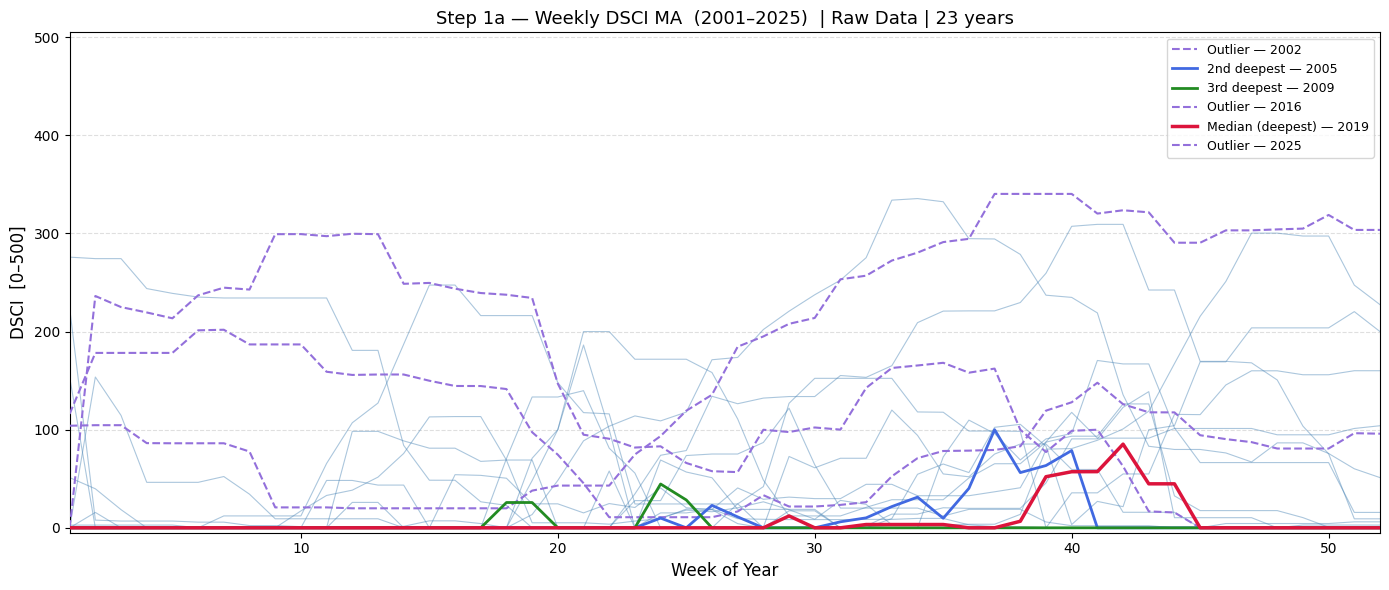

In [4]:
# --- load data once; reuse in 1b and 1c ---
df            = load_and_compute_dsci(DATA_FILE)
matrix, years = build_matrix(df, START_YEAR, END_YEAR)
print(f"Years used: {years[0]}–{years[-1]}  ({len(years)} years)")

# --- band depth on raw data ---
print("Computing Modified Band Depth …")
depths_raw = modified_band_depth(matrix)
print_depth_summary(depths_raw, years)

# --- visualize ---
visualize_curves(
    matrix, years, depths_raw,
    title=(f"Step 1a — Weekly DSCI {STATE}  ({years[0]}–{years[-1]})  "
           f"| Raw Data | {len(years)} years"),
    save_png=True,
    fname=f"step1a_dsci_{STATE}_{years[0]}_{years[-1]}.png",
)

---
## Step 1b — Moving Average Smoothing

Smooth each year's weekly DSCI with a **centered moving average** before computing band depth.

- Removes week-to-week noise
- Window sizes tested: **3, 4, and 5 weeks**
- Band depth + visualization produced for each window

=== Step 1b: Moving Average  (window = 3 weeks) ===
Top-5 most typical years (deepest MBD2):
  1. 2005  (MBD2 = 0.6767)
  2. 2019  (MBD2 = 0.6674)
  3. 2010  (MBD2 = 0.6564)
  4. 2008  (MBD2 = 0.6418)
  5. 2009  (MBD2 = 0.6414)

3 most anomalous years (shallowest MBD2):
  1. 2016  (MBD2 = 0.2565)
  2. 2002  (MBD2 = 0.3376)
  3. 2025  (MBD2 = 0.3815)
Saved → step1b_dsci_MA_ma3.png


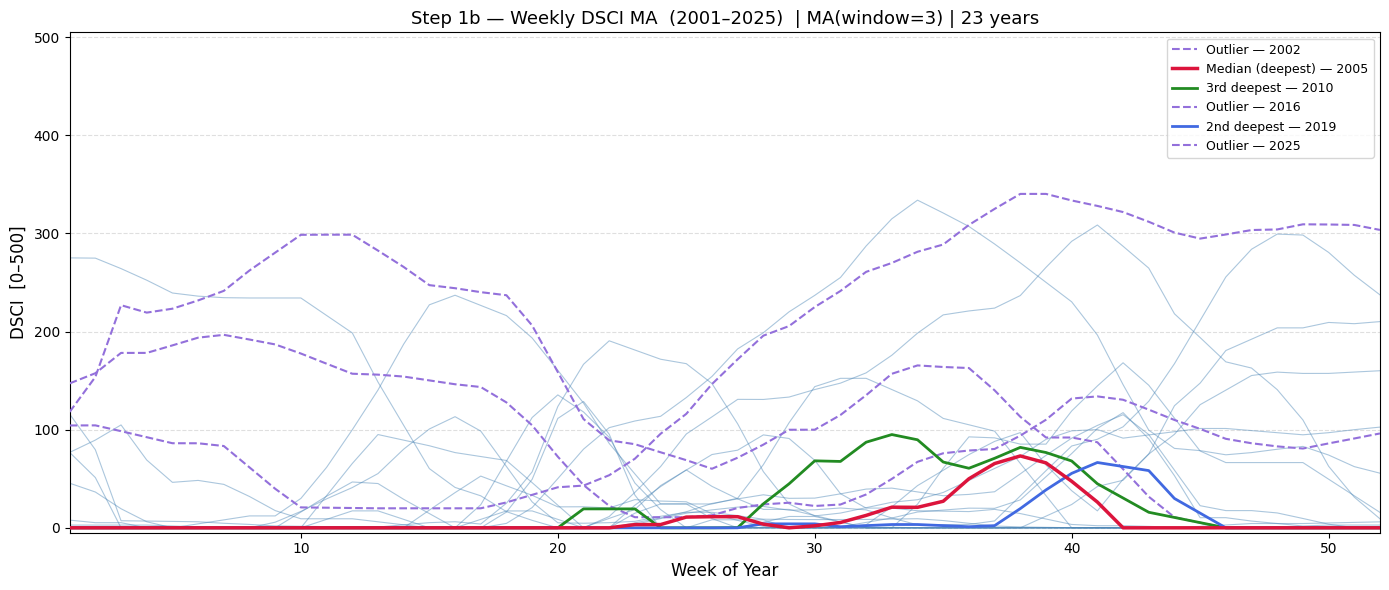

In [5]:
# Window = 3 weeks
window = 3
print(f"=== Step 1b: Moving Average  (window = {window} weeks) ===")
smoothed_3     = apply_moving_average(matrix, window)
depths_ma3     = modified_band_depth(smoothed_3)
print_depth_summary(depths_ma3, years)

visualize_curves(
    smoothed_3, years, depths_ma3,
    title=(f"Step 1b — Weekly DSCI {STATE}  ({years[0]}–{years[-1]})  "
           f"| MA(window={window}) | {len(years)} years"),
    save_png=True,
    fname=f"step1b_dsci_{STATE}_ma{window}.png",
)

=== Step 1b: Moving Average  (window = 4 weeks) ===
Top-5 most typical years (deepest MBD2):
  1. 2005  (MBD2 = 0.6599)
  2. 2010  (MBD2 = 0.6451)
  3. 2019  (MBD2 = 0.6435)
  4. 2008  (MBD2 = 0.6201)
  5. 2009  (MBD2 = 0.6193)

3 most anomalous years (shallowest MBD2):
  1. 2016  (MBD2 = 0.2603)
  2. 2002  (MBD2 = 0.3249)
  3. 2025  (MBD2 = 0.3806)
Saved → step1b_dsci_MA_ma4.png


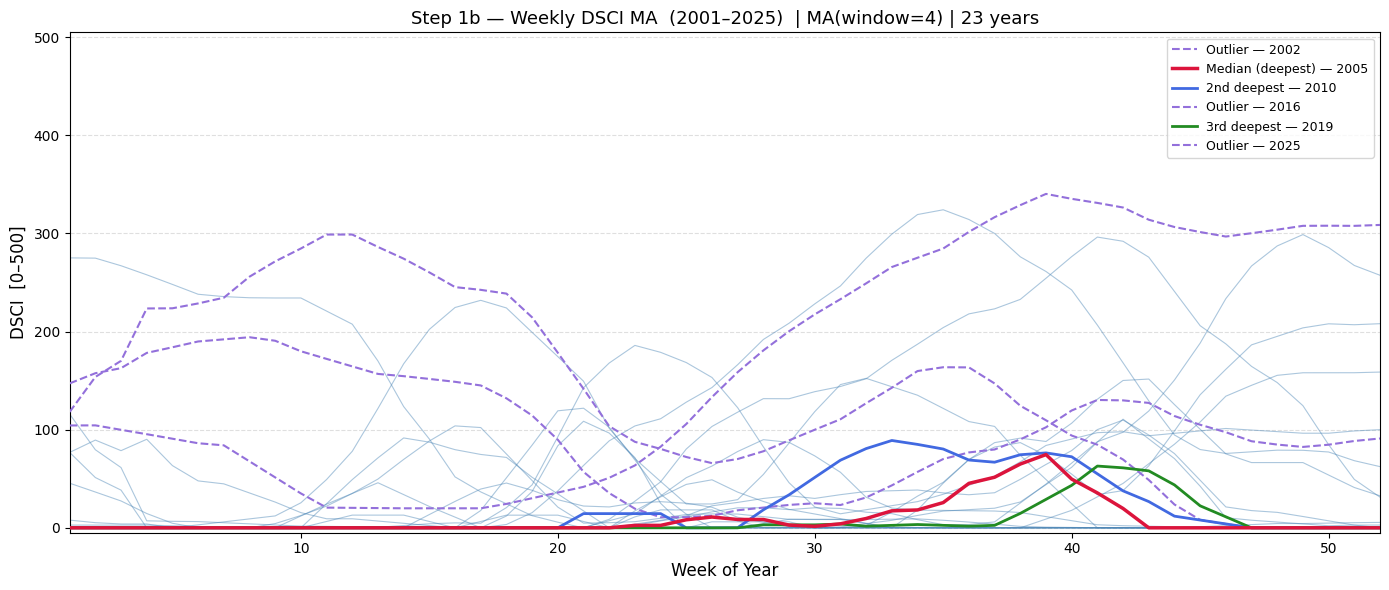

In [6]:
# Window = 4 weeks
window = 4
print(f"=== Step 1b: Moving Average  (window = {window} weeks) ===")
smoothed_4 = apply_moving_average(matrix, window)
depths_ma4 = modified_band_depth(smoothed_4)
print_depth_summary(depths_ma4, years)

visualize_curves(
    smoothed_4, years, depths_ma4,
    title=(f"Step 1b — Weekly DSCI {STATE}  ({years[0]}–{years[-1]})  "
           f"| MA(window={window}) | {len(years)} years"),
    save_png=True,
    fname=f"step1b_dsci_{STATE}_ma{window}.png",
)

=== Step 1b: Moving Average  (window = 5 weeks) ===
Top-5 most typical years (deepest MBD2):
  1. 2005  (MBD2 = 0.6433)
  2. 2010  (MBD2 = 0.6320)
  3. 2019  (MBD2 = 0.6225)
  4. 2009  (MBD2 = 0.6031)
  5. 2008  (MBD2 = 0.6022)

3 most anomalous years (shallowest MBD2):
  1. 2016  (MBD2 = 0.2546)
  2. 2002  (MBD2 = 0.3239)
  3. 2025  (MBD2 = 0.3774)
Saved → step1b_dsci_MA_ma5.png


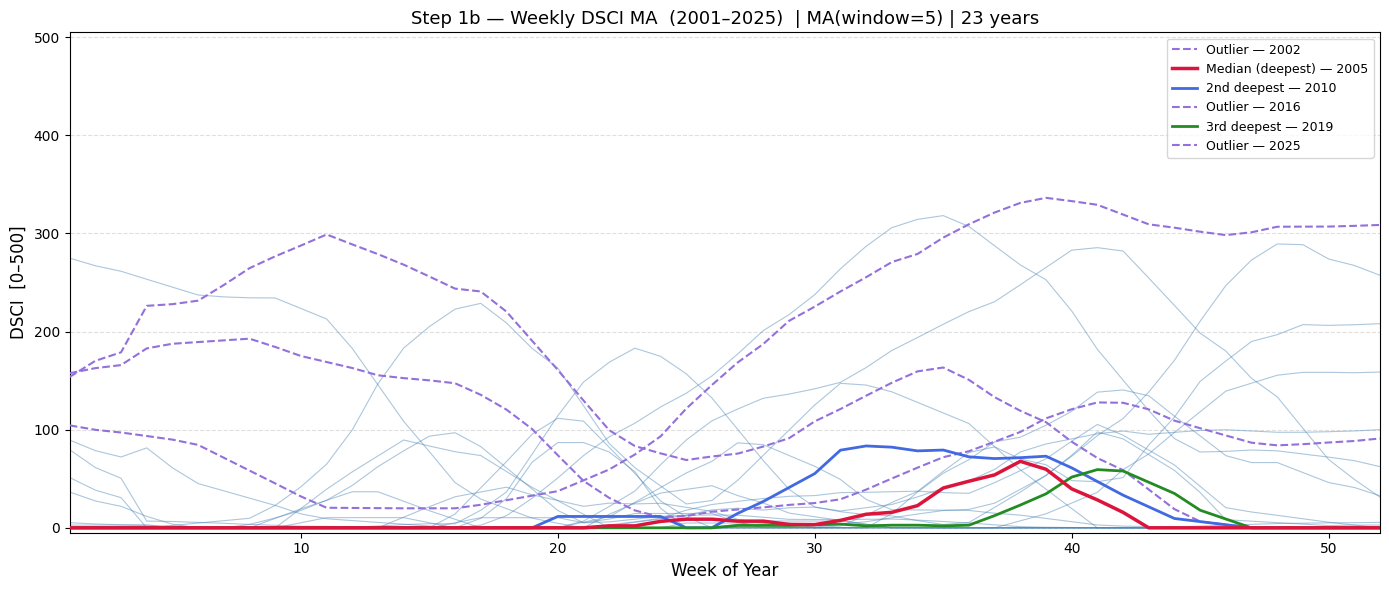

In [7]:
# Window = 5 weeks
window = 5
print(f"=== Step 1b: Moving Average  (window = {window} weeks) ===")
smoothed_5 = apply_moving_average(matrix, window)
depths_ma5 = modified_band_depth(smoothed_5)
print_depth_summary(depths_ma5, years)

visualize_curves(
    smoothed_5, years, depths_ma5,
    title=(f"Step 1b — Weekly DSCI {STATE}  ({years[0]}–{years[-1]})  "
           f"| MA(window={window}) | {len(years)} years"),
    save_png=True,
    fname=f"step1b_dsci_{STATE}_ma{window}.png",
)

---
## Step 1c — Spline Smoothing of the Median Curve

Apply `scipy.interpolate.UnivariateSpline` to the median (deepest) curve found in Step 1a:

- Produces a **differentiable** median curve → enables rate-of-change analysis
- The spline-smoothed median is drawn on top of all existing curves (including outliers)

Median curve year : 2019
Spline smoothing factor s = 780
Saved → step1c_dsci_MA_spline.png


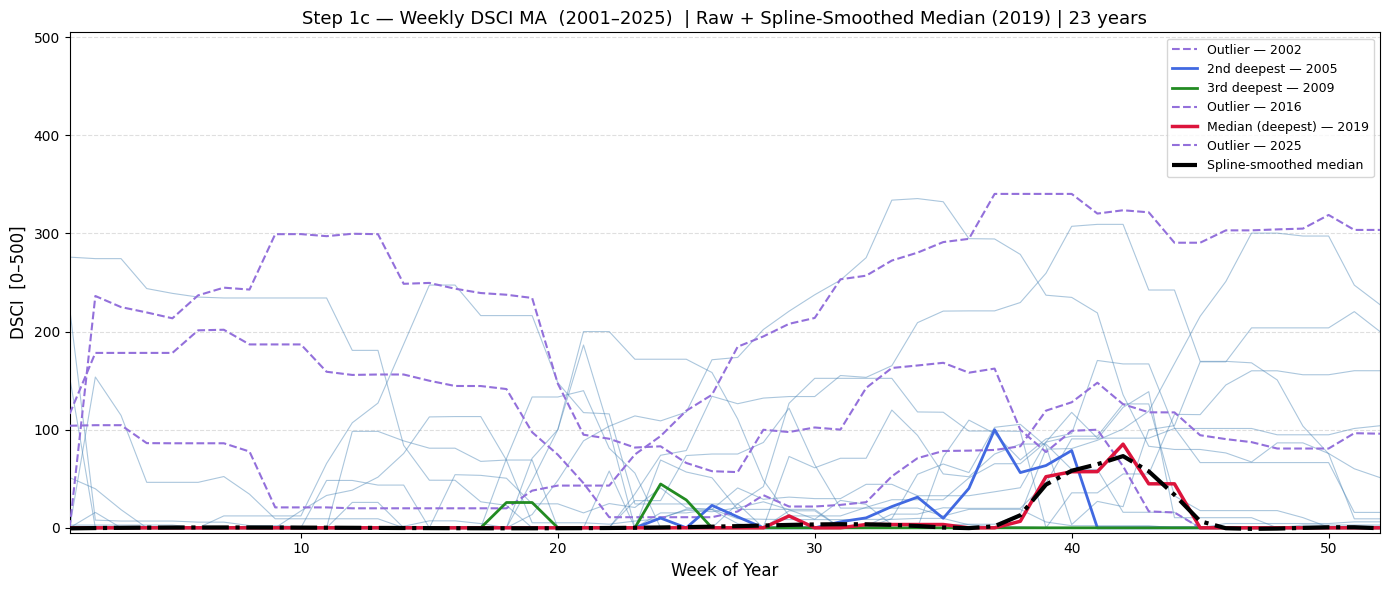

Saved → step1c_dsci_MA_derivative.png


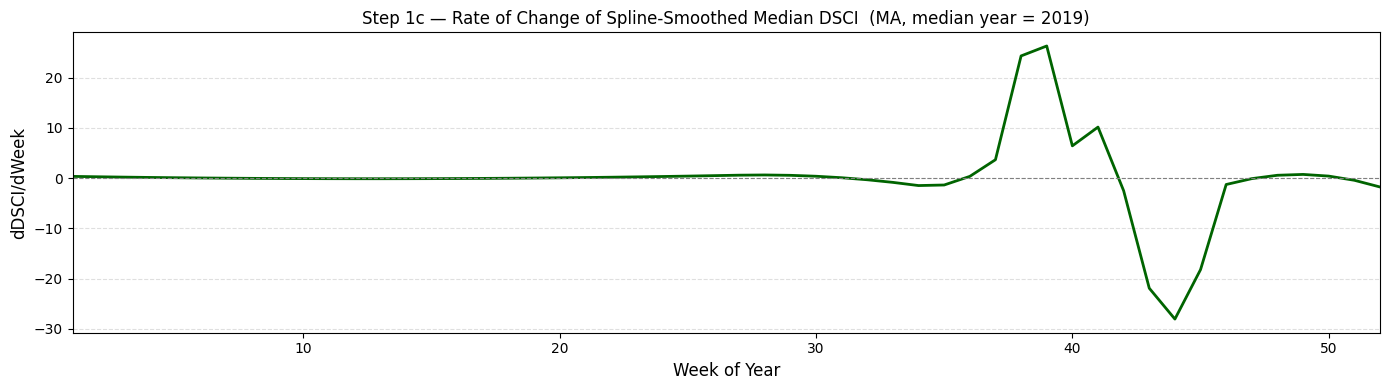

In [8]:
# --- extract median curve from Step 1a ---
med_idx   = int(np.argmax(depths_raw))
med_curve = matrix[med_idx]
weeks     = np.arange(1, matrix.shape[1] + 1)

print(f"Median curve year : {years[med_idx]}")

# --- fit UnivariateSpline  (s controls smoothness; larger s = smoother) ---
s_factor     = len(weeks) * 15          # tune this if needed
spl          = UnivariateSpline(weeks, med_curve, s=s_factor)
spline_curve = spl(weeks)

print(f"Spline smoothing factor s = {s_factor}")

# --- plot all raw curves + spline-smoothed median overlay ---
visualize_curves(
    matrix, years, depths_raw,
    title=(f"Step 1c — Weekly DSCI {STATE}  ({years[0]}–{years[-1]})  "
           f"| Raw + Spline-Smoothed Median ({years[med_idx]}) | {len(years)} years"),
    spline_curve=spline_curve,
    save_png=True,
    fname=f"step1c_dsci_{STATE}_spline.png",
)

# --- first derivative: rate of drought change ---
spl_deriv = spl.derivative()
fig2, ax2 = plt.subplots(figsize=(14, 4))
ax2.plot(weeks, spl_deriv(weeks), color="darkgreen", lw=2)
ax2.axhline(0, color="gray", lw=0.8, ls="--")
ax2.set_xlim(1, len(weeks))
ax2.set_xlabel("Week of Year", fontsize=12)
ax2.set_ylabel("dDSCI/dWeek", fontsize=12)
ax2.set_title(
    f"Step 1c — Rate of Change of Spline-Smoothed Median DSCI  "
    f"({STATE}, median year = {years[med_idx]})",
    fontsize=12,
)
ax2.grid(axis="y", ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig(f"step1c_dsci_{STATE}_derivative.png", dpi=150)
print(f"Saved → step1c_dsci_{STATE}_derivative.png")
plt.show()

---
## Step 2 — Spline-Smoothed Median Curves for All 14 MA Counties

Repeat Steps 1a → 1c for each of the **14 Massachusetts counties** using `data_by_county.csv`:

1. Build a (years × 52) DSCI matrix per county
2. Compute **MBD2** band depth, identify the median year
3. Fit a **UnivariateSpline** to the median curve

Then overlay all 14 county splines **plus** the MA-statewide spline (from Step 1c) on a single figure.

In [9]:
COUNTY_FILE = "data_by_county.csv"

df_county = load_and_compute_dsci_county = None  # defined inline below

def load_county_data(path):
    df = pd.read_csv(path)
    df["MapDate"] = pd.to_datetime(df["MapDate"], format="%Y%m%d")
    df = df.sort_values("MapDate").reset_index(drop=True)
    df["DSCI"] = df["D0"] + df["D1"] + df["D2"] + df["D3"] + df["D4"]
    df["Year"] = df["MapDate"].dt.year
    df["Week"] = df["MapDate"].dt.isocalendar().week.astype(int)
    return df

df_county = load_county_data(COUNTY_FILE)
counties  = sorted(df_county["County"].unique())
weeks     = np.arange(1, 53)

# Per-county: Steps 1a → 1c (raw MBD2, MA-smoothed MBD2, spline on median)
county_data = {}   # county -> {"matrix", "smoothed", "depths", "spline", "med_year"}

for county in counties:
    cdf = df_county[df_county["County"] == county].copy()
    mat, yrs = build_matrix(cdf, START_YEAR, END_YEAR)
    if len(mat) == 0:
        print(f"  [{county}] No usable years — skipped")
        continue
    smoothed = apply_moving_average(mat, window=3)
    depths   = modified_band_depth(smoothed)
    med_idx  = int(np.argmax(depths))
    spl      = UnivariateSpline(weeks, smoothed[med_idx], s=len(weeks) * 15)
    county_data[county] = {
        "matrix":   mat,
        "smoothed": smoothed,
        "depths":   depths,
        "spline":   spl(weeks),
        "med_year": yrs[med_idx],
        "years":    yrs,
    }
    print(f"  {county:<22}  median year = {yrs[med_idx]},  years used = {len(yrs)}")

print(f"\n{len(county_data)} counties ready.")


  Skipping 2001: only 34 weeks
  Skipping 2003: all-zero DSCI
  Skipping 2004: all-zero DSCI
  Skipping 2011: all-zero DSCI
  Skipping 2019: all-zero DSCI
  Barnstable County       median year = 2005,  years used = 20
  Skipping 2001: only 34 weeks
  Skipping 2003: all-zero DSCI
  Skipping 2008: all-zero DSCI
  Skipping 2011: all-zero DSCI
  Berkshire County        median year = 2007,  years used = 21
  Skipping 2001: only 34 weeks
  Skipping 2003: all-zero DSCI
  Skipping 2004: all-zero DSCI
  Skipping 2011: all-zero DSCI
  Bristol County          median year = 2010,  years used = 21
  Skipping 2001: only 34 weeks
  Skipping 2003: all-zero DSCI
  Skipping 2004: all-zero DSCI
  Skipping 2009: all-zero DSCI
  Skipping 2011: all-zero DSCI
  Dukes County            median year = 2010,  years used = 20
  Skipping 2001: only 34 weeks
  Skipping 2003: all-zero DSCI
  Skipping 2009: all-zero DSCI
  Essex County            median year = 2011,  years used = 22
  Skipping 2001: only 34 weeks
  S

Saved → step2_county_individual_grid.png


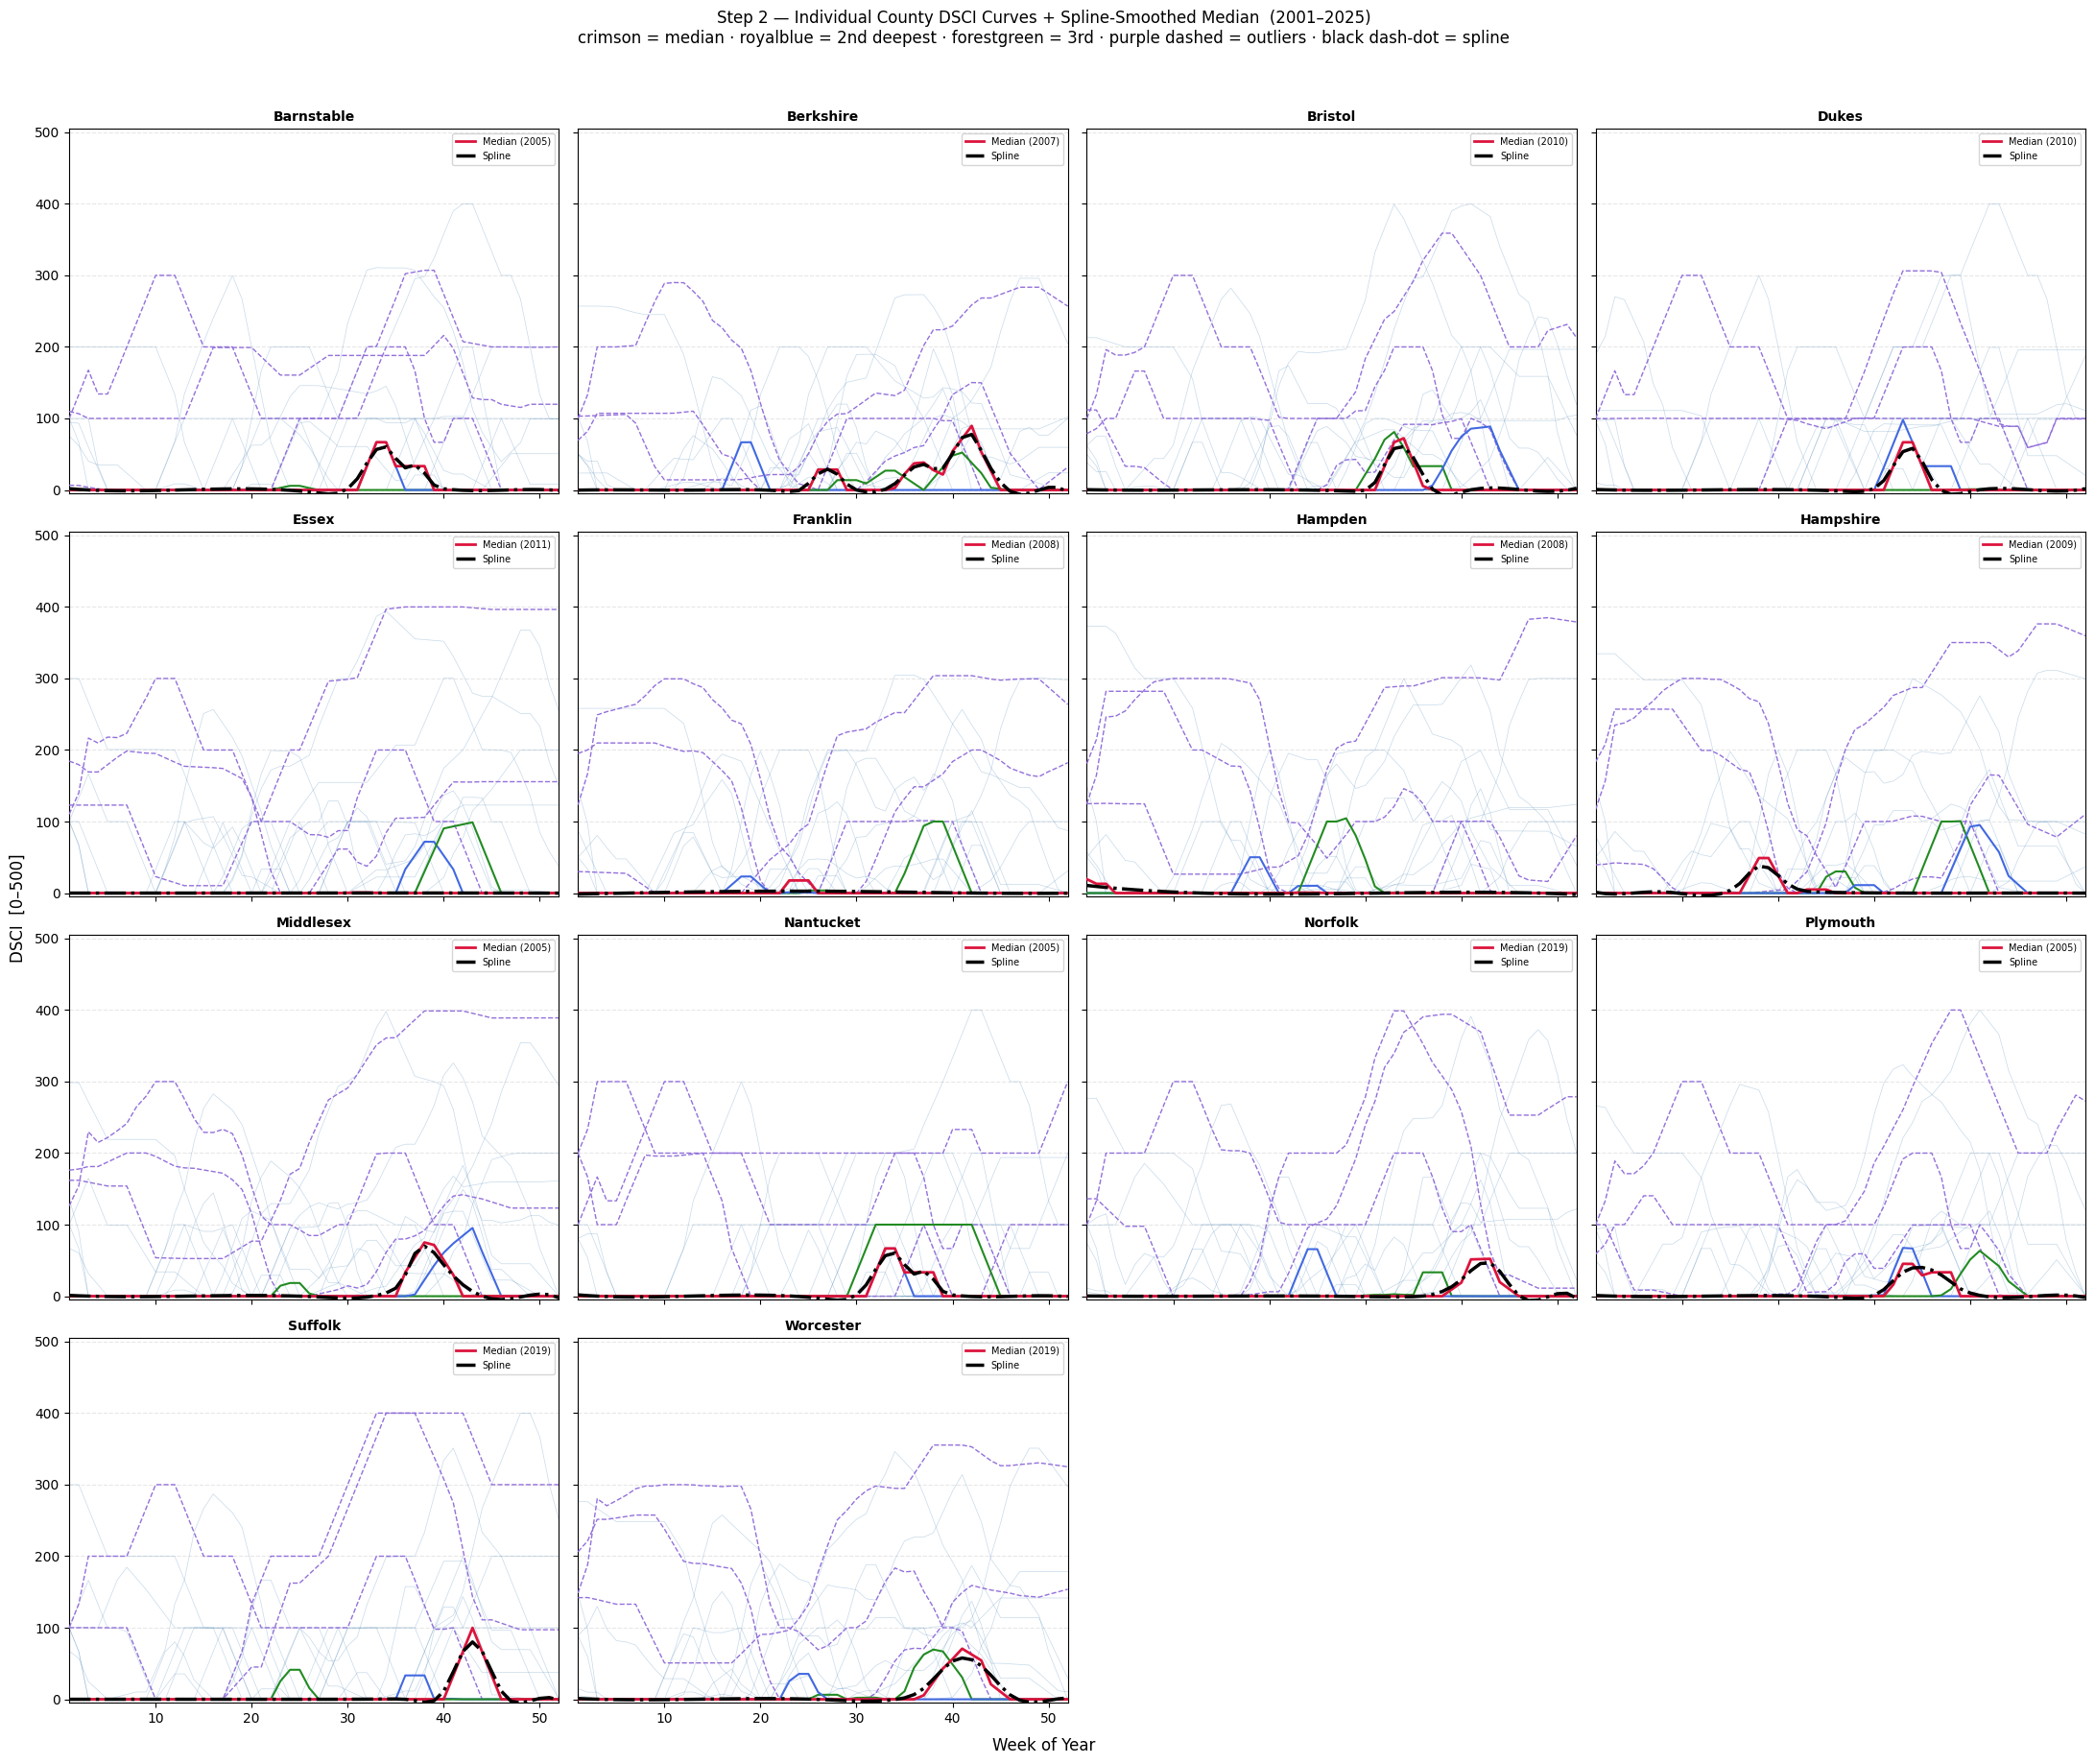

In [10]:
# ── Figure 1: 4×4 grid — individual county curves + spline ─────────────────
NCOLS, NROWS = 4, 4
fig, axes    = plt.subplots(NROWS, NCOLS, figsize=(22, 18), sharex=True, sharey=True)
axes_flat    = axes.flatten()

cmap   = matplotlib.colormaps["tab20"]
colors = {c: cmap(i / len(county_data)) for i, c in enumerate(county_data)}

for ax_idx, (county, cd) in enumerate(county_data.items()):
    ax      = axes_flat[ax_idx]
    mat     = cd["smoothed"]
    depths  = cd["depths"]
    spline  = cd["spline"]
    yrs     = cd["years"]

    sorted_idx  = np.argsort(depths)[::-1]
    outlier_set = set(sorted_idx[-3:])

    for i, curve in enumerate(mat):
        if i == sorted_idx[0]:
            ax.plot(weeks, curve, color="crimson", lw=2.0, zorder=5,
                    label=f"Median ({yrs[sorted_idx[0]]})")
        elif i == sorted_idx[1]:
            ax.plot(weeks, curve, color="royalblue", lw=1.5, zorder=4)
        elif i == sorted_idx[2]:
            ax.plot(weeks, curve, color="forestgreen", lw=1.5, zorder=4)
        elif i in outlier_set:
            ax.plot(weeks, curve, color="mediumpurple", lw=1.0, ls="--", zorder=3)
        else:
            ax.plot(weeks, curve, color="steelblue", lw=0.5, alpha=0.30, zorder=2)

    ax.plot(weeks, spline, color="black", lw=2.5, ls="-.", zorder=6,
            label="Spline")

    short = county.replace(" County", "")
    ax.set_title(short, fontsize=10, fontweight="bold")
    ax.set_ylim(-5, 505)
    ax.set_xlim(1, 52)
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(axis="y", ls="--", alpha=0.3)

for ax in axes_flat[len(county_data):]:
    ax.set_visible(False)

fig.supxlabel("Week of Year", fontsize=12, y=0.01)
fig.supylabel("DSCI  [0–500]", fontsize=12, x=0.01)
fig.suptitle(
    f"Step 2 — Individual County DSCI Curves + Spline-Smoothed Median  ({START_YEAR}–{END_YEAR})\n"
    "crimson = median · royalblue = 2nd deepest · forestgreen = 3rd · purple dashed = outliers · black dash-dot = spline",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.savefig("step2_county_individual_grid.png", dpi=150, bbox_inches="tight")
print("Saved → step2_county_individual_grid.png")
plt.show()


  Skipping 2003: all-zero DSCI
  Skipping 2011: all-zero DSCI
Saved → step2_county_combined_splines.png


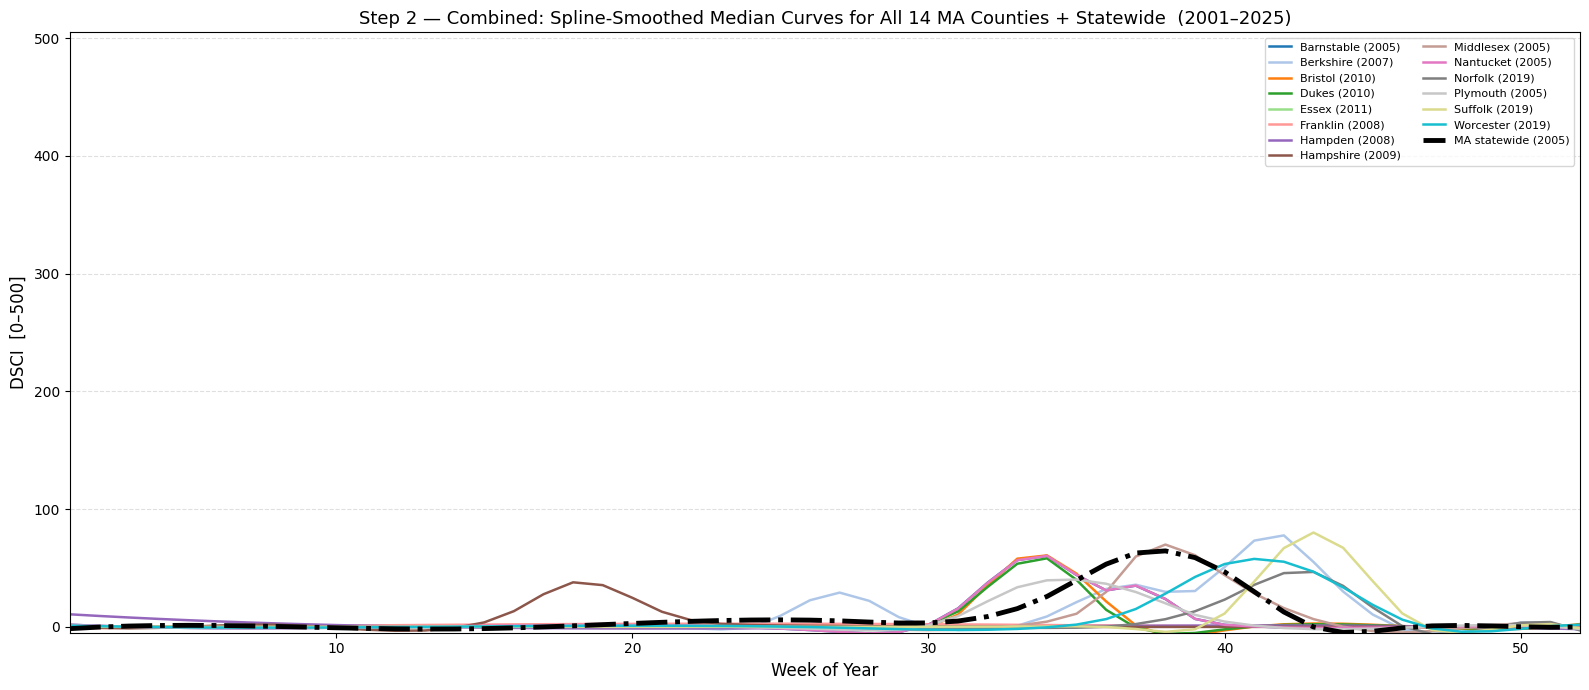

In [11]:
# ── Figure 2: Combined overlay — all 14 county splines + MA statewide ───────
cmap_combined = matplotlib.colormaps["tab20"]
colors_list   = [cmap_combined(i / len(county_data)) for i in range(len(county_data))]

fig, ax = plt.subplots(figsize=(16, 7))

for (county, cd), color in zip(county_data.items(), colors_list):
    short = county.replace(" County", "")
    ax.plot(weeks, cd["spline"], lw=1.8, color=color,
            label=f"{short} ({cd['med_year']})")

# MA statewide spline (recomputed from Step 1c data)
ma_mat, ma_yrs  = build_matrix(df, START_YEAR, END_YEAR)
ma_depths       = modified_band_depth(apply_moving_average(ma_mat, 3))
ma_med_idx      = int(np.argmax(ma_depths))
ma_med_curve    = apply_moving_average(ma_mat, 3)[ma_med_idx]
ma_spl          = UnivariateSpline(weeks, ma_med_curve, s=len(weeks) * 15)

ax.plot(weeks, ma_spl(weeks), color="black", lw=3.5, ls="-.", zorder=10,
        label=f"MA statewide ({ma_yrs[ma_med_idx]})")

ax.set_xlim(1, 52)
ax.set_ylim(-5, 505)
ax.set_xlabel("Week of Year", fontsize=12)
ax.set_ylabel("DSCI  [0–500]", fontsize=12)
ax.set_title(
    f"Step 2 — Combined: Spline-Smoothed Median Curves for All 14 MA Counties + Statewide  "
    f"({START_YEAR}–{END_YEAR})",
    fontsize=13,
)
ax.legend(fontsize=8, loc="upper right", ncol=2)
ax.grid(axis="y", ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig("step2_county_combined_splines.png", dpi=150)
print("Saved → step2_county_combined_splines.png")
plt.show()
